Training


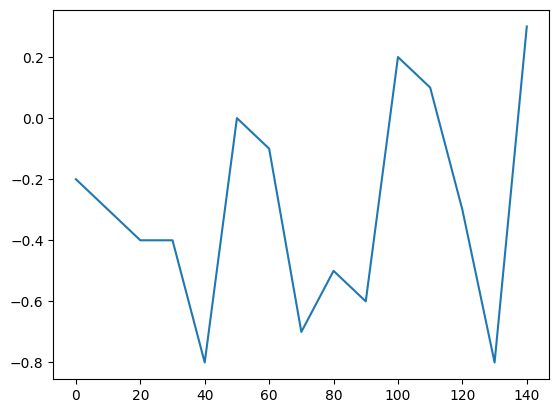

Testing


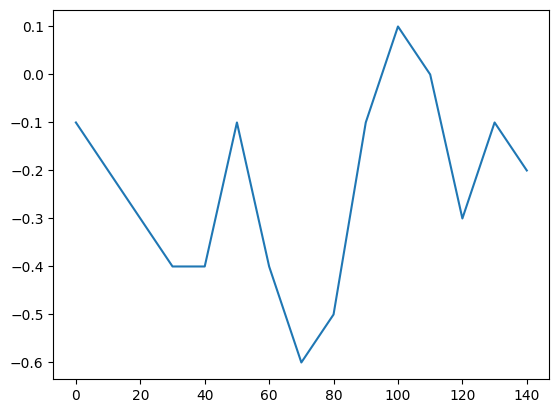

Solution:
Dealer: 1, Sum: 12, Ace: yes --> Stand
Dealer: 1, Sum: 13, Ace: yes --> Stand


IndexError: index 2 is out of bounds for axis 2 with size 2

In [11]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make("Blackjack-v1", natural=False, sab=False, render_mode="rgb_array")

epsilon = 1
q_table = np.zeros([space.n for space in env.observation_space] + [env.action_space.n])
lr_start = 0.5
lr_end = 0.05
step_size = lr_start
discount = 1
episodes = 150
test = []
train = []

def show_ep():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

for ep in range(episodes):
    done = False
    epsilon -= (2/episodes)*epsilon
    step_size = lr_start / (1 + (lr_start-lr_end) / (lr_end*episodes) * ep)
    obs, info = env.reset()
    step = 0

    while not done:
        step += 1
        last_state = obs

        action = (env.action_space.sample() if np.random.rand()<epsilon else np.argmax(q_table[obs]))
        obs, reward, terminated, truncated, info = env.step(action)
        done = truncated or terminated

        if done:
            train.append(reward)
            q_table[last_state][action] += step_size* (reward - q_table[last_state][action])
            if reward>0:
                found = ep
            #show_ep()
            #print(ep,step,reward)
        else:
            q_table[last_state][action] += step_size* (reward + discount*np.max(q_table[obs]) - q_table[last_state][action])


    obs, info = env.reset()
    done = False
    while not done:
        obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
        done = truncated or terminated
        if done:
            test.append(reward)

print('Training')
window = 10
x = range(0,episodes,window)
avg_train = [float(np.mean(train[i:i+window])) for i in x]
plt.plot(x,avg_train)
plt.show()

print('Testing')
avg_test = [float(np.mean(test[i:i+window])) for i in x]
plt.plot(x,avg_test)
plt.show()

print("Solution:")
for i, usable_ace in enumerate(["yes", "no"]):
    for dealer_card in range(1, 11):
        for player_sum in range(12, 22):
            action = np.argmax(q_table[i, dealer_card-1, player_sum-12])
            print(f"Dealer: {dealer_card}, Sum: {player_sum}, Ace: {usable_ace} -->", ['Stand', 'Hit'][action])